# Project: Investigate SuperStore Dataset

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#inspection">Data Inspection</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#Exploratory">Exploratory Data Analysis</a></li>
<li><a href="#viz">Data Visualizations</a></li>
<li><a href="#conclusions">Conclusions</a></li>
<li><a href="#recommendations">Recommendations</a></li>
</ul>

<a i='intro'></a>
## Introduction
### SuperStore Analysis Report

#### 1. Dataset Introduction
In this report, we analyze a comprehensive SuperStore sales dataset to understand the key factors influencing business performance, profitability, and customer purchasing behavior. The dataset records various transactional details, including customer segments, product categories, geographic locations (cities and states), discount levels, shipping modes, and financial metrics such as sales and profits. The primary goal is to uncover data-driven patterns and actionable insights that help stakeholders optimize discount strategies, improve regional profitability, and maximize overall revenue.

#### 2. Dependent and Independent Variables
To drive our analysis, the report is structured around core dependent and independent variables:
* **Dependent Variables:** 
  * `Sales` (Total revenue generated per transaction).
  * `Profit / Profit Margin` (Net financial gain or loss).
  * `Order Volume / Frequency` (Number of orders placed).
* **Independent Variables:**
  * `Segment` (Customer categories: Consumer, Corporate, Home Office).
  * `Discount` (Percentage of discount applied to orders).
  * `Category / Sub-Category` (Product classifications).
  * `State / City / Region` (Geographic locations of customers).
  * `Shipping Duration` (Time elapsed between order and ship dates).

#### 3. Research Questions
Throughout this report, we aim to answer the following analytical questions based on our data exploration and visualizations:
1. Which customer segment (Consumer, Corporate, Home Office) contributes the highest profit margin and total revenue?
2. Who are the top 10 high-value customers based on total sales & frequency of orders?
3. Which top 10 states generate the lowest or negative total profits?
4. Is there a relationship between shipping duration and the total number of orders or sales volume?
5. What are the monthly and yearly trendlines for total sales and profits?
6. How is total sales distributed across different product categories?
7. What is the total order volume and Sales contribution per city?
8. How do different discount levels impact profit margins across various product sub-categories?

<a id='inspection'></a>
## **1. Data Inspection**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
superstore = pd.read_excel(r'..\RawData\Superstore.xls')
superstore.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
superstore.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3428,3429,US-2019-111024,2019-07-03,2019-07-06,Second Class,SZ-20035,Sam Zeldin,Home Office,United States,Lancaster,...,43130.0,East,FUR-TA-10002041,Furniture,Tables,"Bevis Round Conference Table Top, X-Base",215.148,2,0.4,-103.9882
8982,8983,CA-2018-110898,2018-03-06,2018-03-12,Standard Class,LC-16870,Lena Cacioppo,Consumer,United States,Chicago,...,60623.0,Central,OFF-BI-10004656,Office Supplies,Binders,Peel & Stick Add-On Corner Pockets,1.728,4,0.8,-2.7648
2436,2437,CA-2019-140053,2019-07-03,2019-07-10,Standard Class,CA-12265,Christina Anderson,Consumer,United States,Farmington,...,87401.0,West,FUR-FU-10003708,Furniture,Furnishings,Tenex Traditional Chairmats for Medium Pile Ca...,545.850,9,0.0,114.6285
8363,8364,CA-2019-147207,2019-01-02,2019-01-04,Second Class,TS-21655,Trudy Schmidt,Consumer,United States,El Paso,...,79907.0,Central,OFF-ST-10002615,Office Supplies,Storage,"Dual Level, Single-Width Filing Carts",372.144,3,0.2,27.9108
9320,9321,US-2019-108343,2019-07-20,2019-07-25,Standard Class,AR-10825,Anthony Rawles,Corporate,United States,New York City,...,10009.0,East,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,183.920,4,0.0,31.2664


In [4]:
superstore.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State           9994 non-null   str           
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   str           
 13  Product ID      9994 non-null   str           
 14  Category        9994 non-null   str           
 15  Sub-Category   

In [5]:
superstore.nunique()

Row ID            9994
Order ID          5009
Order Date        1236
Ship Date         1334
Ship Mode            4
Customer ID        793
Customer Name      793
Segment              3
Country/Region       1
City               531
State               49
Postal Code        630
Region               4
Product ID        1862
Category             3
Sub-Category        17
Product Name      1850
Sales             6144
Quantity            14
Discount            12
Profit            7545
dtype: int64

 *We can convert Data types for Ship Mode, Segment, Country/Region, State, Region, Category, Sub-Category to be 'Category' and Postal Code to be 'str' to save more memory*

In [6]:
superstore.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2018-04-30 10:03:51.979187,2018-05-04 09:03:29.645787,55245.233297,229.858001,3.789574,0.156203,28.656896
min,1.000000,2016-01-03 00:00:00,2016-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2017-05-23 00:00:00,2017-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2018-06-26 00:00:00,2018-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2019-05-14 00:00:00,2019-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2019-12-30 00:00:00,2020-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108


Sales has Max 22638.480000 while average sales is 229.858001 , we will see if it is outlier or not 

Profit has min -6599.978000 and max 8399.976000 while average sales are 28.656896 so we will see

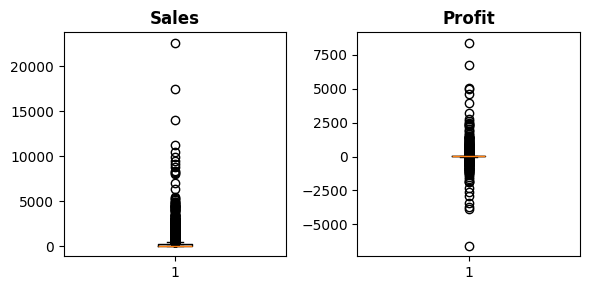

In [7]:
# Sales and Profit Boxplot to check outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

ax1.boxplot(superstore['Sales'])
ax1.set_title('Sales', fontweight='bold')

ax2.boxplot(superstore['Profit'])
ax2.set_title('Profit', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
superstore[superstore['Sales'] > 5000].count()['Sales']

np.int64(19)

I found that there are 19 values only greater than 5000 from all the 9994 Sale Rows!

In [9]:
superstore[(superstore['Profit'] < -2500) | (superstore['Profit'] > 2500)].count()['Profit']

np.int64(16)

I found that there are 16 values only greater than 2500 and less than -2500 from all the 9994 Profit Rows!

## **Decision on Outliers (Sales & Profit)**

After statistical inspection, we decided not to remove the extreme values (outliers) for both Sales and Profit for the following reasons:

* **Business Context & Validity:** Extreme values in retail datasets (such as very high sales) typically represent legitimate B2B bulk orders or high-value corporate transactions rather than data entry errors. Removing them would discard critical, high-impact business revenue insights.

* **Risk of Distortion:** Deleting extreme profit losses or gains would mask vital risk factors (e.g., severe losses or exceptionally profitable products), which are essential for management decision-making and risk assessment.

* **Analytic Integrity:** Preserving the raw dataset ensures that our exploratory data analysis (EDA) and future predictive models reflect the true, unvarnished retail environment.

In [10]:
superstore.isna().sum()[superstore.isna().sum() > 0]

Postal Code    11
dtype: int64

In [11]:
superstore[superstore['Postal Code'].isna()==True]['City'].unique()

<StringArray>
['Burlington']
Length: 1, dtype: str

Postal Code column has 11 null values but all of it from Burlington city so we can try to fix it

In [12]:
superstore.duplicated().sum()

np.int64(0)

Superstore dataset has no duplicated values

<a id='wrangling'></a>
## **2. Data Wrangling**

Start with change datatype to category so the change Complete to all values and send alert if there is a column name changed or other errors

In [13]:
try:  
    for col in ['Ship Mode', 'Segment', 'Country/Region', 'State', 'Region', 'Category', 'Sub-Category']:
        if col in superstore.columns:
            superstore[col] = superstore[col].astype('category')
        else:
            print(f"Warning: Column '{col}' not found in DataFrame.")
            
except Exception as ex:
    print(f"An unexpected error occurred: {ex}")

Change Postal Code to Str

In [14]:
try:
    superstore['Postal Code'] = superstore['Postal Code'].astype('str')
except Exception as ex:
    print(f"An unexpected error occurred or column name changed!: {ex}")

#### Feature Engineering Code Summary
**Profit Margin:**
  Calculates the profitability ratio by dividing the profit by total sales.

In [15]:
superstore['Profit Margin'] = superstore['Profit'] / superstore['Sales']


**Shipping Duration:**
  Calculates the delivery time in days by finding the difference between the shipping date and the order date

Note: (.dt.days) to convert it from timedelta64(3 days) to int64(3) so we deal with it as numbers

In [16]:
superstore['Shipping Duration'] = (superstore['Ship Date'] - superstore['Order Date']).dt.days

  **Sales Performance:**
  Categorizes order performance into 'Profitable' or 'Loss' based on the profit value using NumPy.

In [17]:
superstore['Sales Performance'] = np.where(superstore['Profit'] > 0, 'Profitable', 'Loss')

superstore['Sales Performance'] = superstore['Sales Performance'].astype('category')

In [18]:
superstore[['Profit Margin','Shipping Duration','Sales Performance']].sample(5)

,Profit Margin,Shipping Duration,Sales Performance
7367,-0.071429,6,Loss
4572,0.187500,4,Profitable
1839,0.162500,4,Profitable
7213,0.490000,4,Profitable
3471,0.325000,5,Profitable


In [19]:
superstore['Months'] = superstore['Order Date'].dt.month

Null values: by search i found Burlington postal code is 05401 it starts with 0 and with postal code has wrong type (float) sure it will be null so let's fix it

In [20]:
superstore['Postal Code'] = superstore['Postal Code'].fillna('05401')
superstore.isna().sum()['Postal Code']

np.int64(0)

In [21]:
superstore.info()      #reduced memory usage by 0.3 after adding 3 columns and changing types for better performance.

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             9994 non-null   int64         
 1   Order ID           9994 non-null   str           
 2   Order Date         9994 non-null   datetime64[us]
 3   Ship Date          9994 non-null   datetime64[us]
 4   Ship Mode          9994 non-null   category      
 5   Customer ID        9994 non-null   str           
 6   Customer Name      9994 non-null   str           
 7   Segment            9994 non-null   category      
 8   Country/Region     9994 non-null   category      
 9   City               9994 non-null   str           
 10  State              9994 non-null   category      
 11  Postal Code        9994 non-null   str           
 12  Region             9994 non-null   category      
 13  Product ID         9994 non-null   str           
 14  Category           

In [22]:
superstore.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Profit Margin', 'Shipping Duration', 'Sales Performance',
       'Months'],
      dtype='str')

<a id='Exploratory'></a>
## **4. Exploratory Data Analysis (EDA)**

1. Which customer segment (Consumer, Corporate, Home Office) contributes the highest profit margin and total revenue?

In [23]:
EDA1 = superstore.groupby('Segment').agg({'Sales' :'sum', 'Profit Margin' : 'mean'}).reset_index().round({'Sales': 2})
EDA1

,Segment,Sales,Profit Margin
0,Consumer,1161401.34,0.112050
1,Corporate,706146.37,0.121203
2,Home Office,429653.15,0.142870


2. Who are the top 10 high-value customers based on total sales & frequency of orders?

In [24]:
EDA2 = superstore.groupby('Customer Name').agg({'Sales' :'sum', 'Order ID' : 'nunique'}).reset_index().rename(columns={'Sales':'Total Sales','Order ID':'Total Orders'}).sort_values(by='Total Orders', ascending=False).head(10)
EDA2

,Customer Name,Total Sales,Total Orders
259,Emily Phan,5478.0608,17
663,Sally Hughsby,3406.8395,13
574,Noel Staavos,2964.8230,13
586,Patrick Gardner,3086.9070,13
791,Zuschuss Carroll,8025.7070,13
381,Joel Eaton,6760.8150,13
267,Erin Ashbrook,2846.7050,13
145,Chloris Kastensmidt,3154.8550,13
728,Suzanne McNair,5563.3920,12
629,Rick Bensley,4715.4660,12


3. Which top 10 states generate the lowest or negative total profits?

In [25]:
EDA3 = superstore.groupby('State')['Profit'].sum().sort_values().reset_index().rename(columns={'Profit':'Total Profit'}).head(10)
EDA3

,State,Total Profit
0,Texas,-25729.3563
1,Ohio,-16971.3766
2,Pennsylvania,-15559.9603
3,Illinois,-12607.8870
4,North Carolina,-7490.9122
5,Colorado,-6527.8579
6,Tennessee,-5341.6936
7,Arizona,-3427.9246
8,Florida,-3399.3017
9,Oregon,-1190.4705


4. Is there a relationship between shipping duration and the total number of orders or sales volume?

In [26]:
EDA4 = superstore.groupby('Shipping Duration')['Order ID'].nunique().sort_index().reset_index().rename(columns={'Order ID':'Total Orders'})
EDA4

,Shipping Duration,Total Orders
0,0,252
1,1,182
2,2,677
3,3,508
4,4,1401
5,5,1085
6,6,596
7,7,308


5. What are the monthly trendlines for total sales and profits?

In [27]:
EDA5 = superstore.groupby('Months')[['Sales','Profit']].sum().reset_index()
EDA5

,Months,Sales,Profit
0,1,94924.8356,9134.4461
1,2,59751.2514,10294.6107
2,3,205005.4888,28594.6872
3,4,137762.1286,11587.4363
4,5,155028.8117,22411.3078
5,6,152718.6793,21285.7954
6,7,147238.0970,13832.6648
7,8,159044.0630,21776.9384
8,9,307649.9457,36857.4753
9,10,200322.9847,31784.0413


6. How is total sales distributed across different product categories

In [28]:
EDA6 = superstore.groupby('Category')['Sales'].sum().reset_index()
EDA6

,Category,Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


7. What is the total order volume and Sales contribution per city?

In [29]:
EDA7 = superstore.groupby('City').agg({'Order ID':'nunique','Sales':'sum'}).reset_index().rename(columns={'Order ID':'Total Orders','Sales':'Total Sales'}).sort_values(by='Total Orders',ascending=False)
EDA7

,City,Total Orders,Total Sales
329,New York City,450,256368.161
266,Los Angeles,384,175851.341
438,San Francisco,265,112669.092
374,Philadelphia,265,109077.013
452,Seattle,212,119540.742
...,...,...,...
507,Waterloo,1,30.320
510,Wausau,1,317.480
1,Abilene,1,1.392
529,Yucaipa,1,50.800


8. How do different discount levels impact profit margins across various product sub-categories?

In [30]:
EDA8 = superstore.groupby(['Sub-Category', 'Discount'])['Profit Margin'].mean().reset_index()
EDA8.sample(5)

,Sub-Category,Discount,Profit Margin
56,Tables,0.5,-0.638333
2,Appliances,0.0,0.294686
8,Binders,0.0,0.475371
51,Tables,0.0,0.193889
23,Copiers,0.0,0.433636


<a id='viz'></a>
## **5. Data Visualizations**

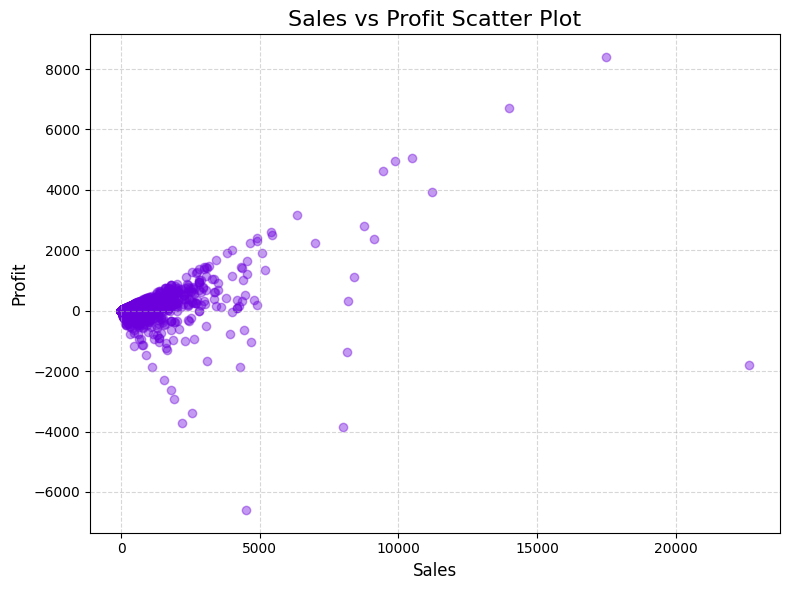

In [31]:
# Correlation between Sales & Profit in Scatter Plot

plt.figure(figsize=(8, 6))

plt.scatter(superstore['Sales'], superstore['Profit'], alpha=0.4, color="#6b00dd")

plt.title('Sales vs Profit Scatter Plot', fontsize=16)
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

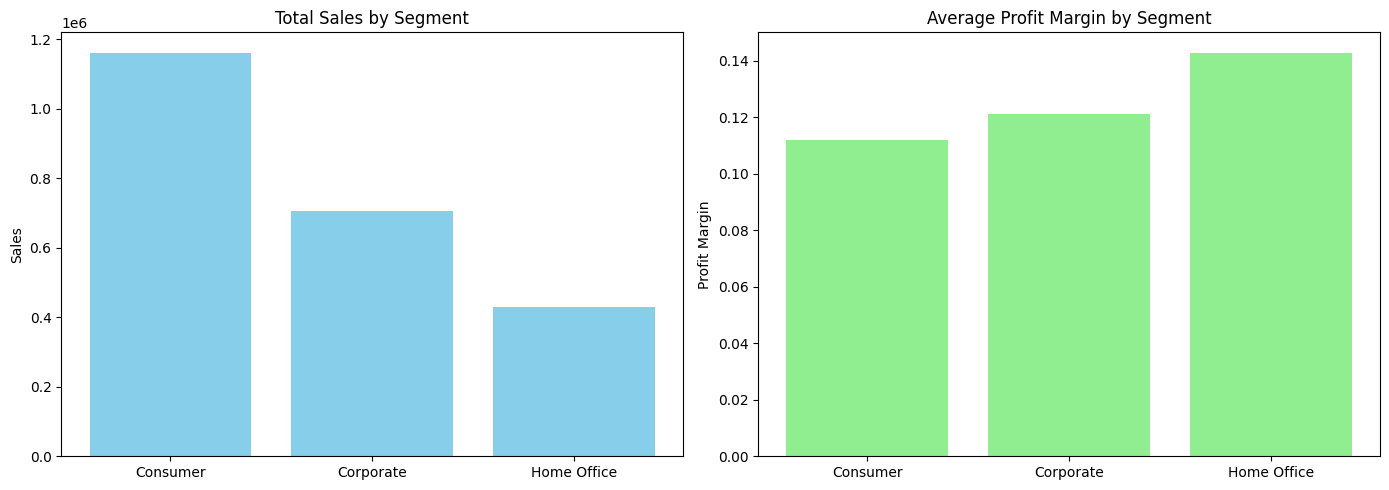

In [32]:
# Total Sales & Average Profit Margin by Segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Sales Graph
axes[0].bar(EDA1['Segment'], EDA1['Sales'] , color='skyblue' )
axes[0].set_title('Total Sales by Segment')
axes[0].set_ylabel('Sales')

# 2. Average Profit Margin by Segment
axes[1].bar(EDA1['Segment'], EDA1['Profit Margin'], color='lightgreen')
axes[1].set_title('Average Profit Margin by Segment')
axes[1].set_ylabel('Profit Margin')

plt.tight_layout()
plt.show()

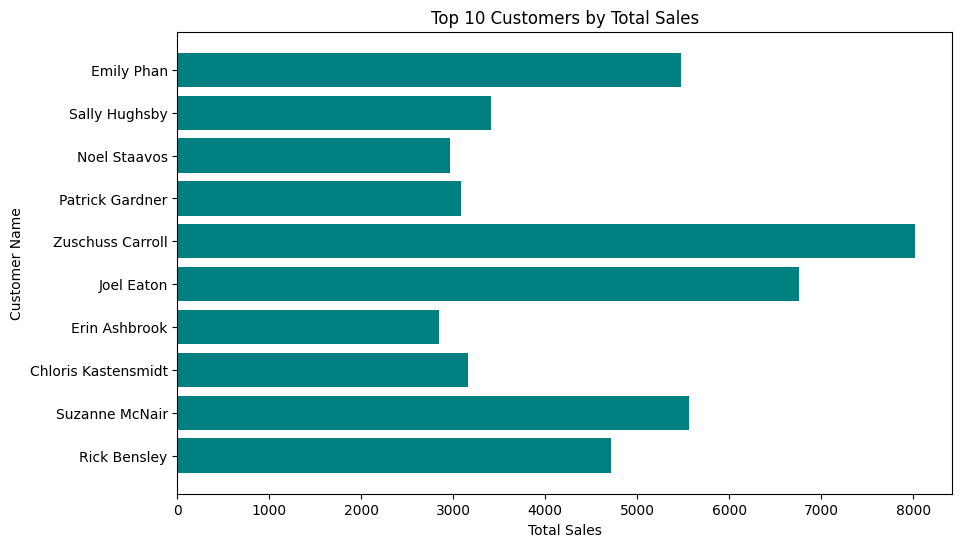

In [33]:
# Top 10 Customers by Total Sales
plt.figure(figsize=(10, 6))

plt.barh(EDA2['Customer Name'], EDA2['Total Sales'], color='teal')
plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer Name')
plt.gca().invert_yaxis()
plt.show()

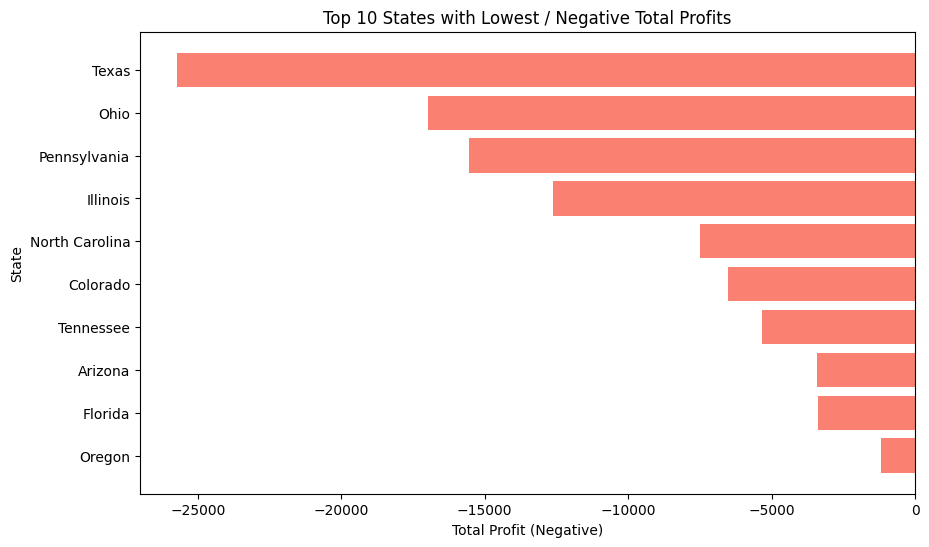

In [34]:
# Top 10 States with Lowest / Negative Total Profits
plt.figure(figsize=(10, 6))

plt.barh(EDA3['State'], EDA3['Total Profit'], color='salmon')
plt.title('Top 10 States with Lowest / Negative Total Profits')
plt.xlabel('Total Profit (Negative)')
plt.ylabel('State')
plt.gca().invert_yaxis()

plt.show()

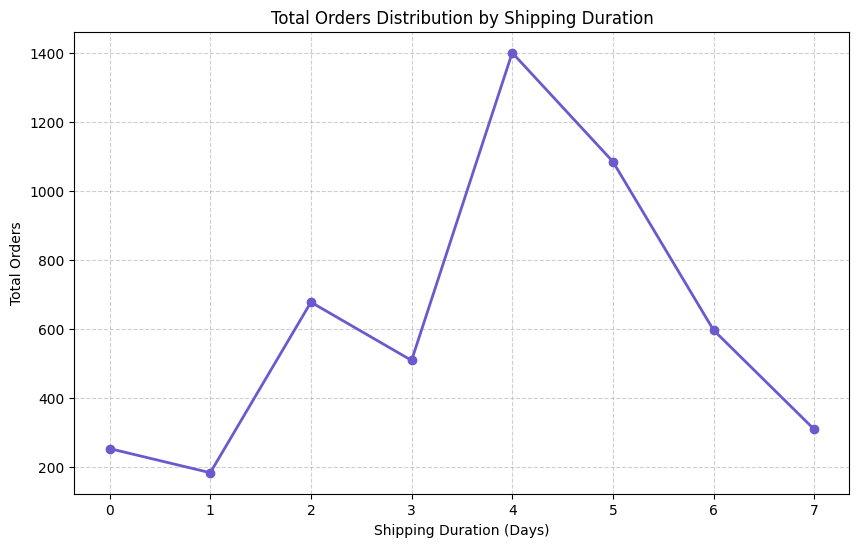

In [35]:
# Total Orders Distribution by Shipping Duration
plt.figure(figsize=(10, 6))
plt.plot(EDA4['Shipping Duration'], EDA4['Total Orders'], marker='o', color='slateblue', linewidth=2)
plt.title('Total Orders Distribution by Shipping Duration')
plt.xlabel('Shipping Duration (Days)')
plt.ylabel('Total Orders')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

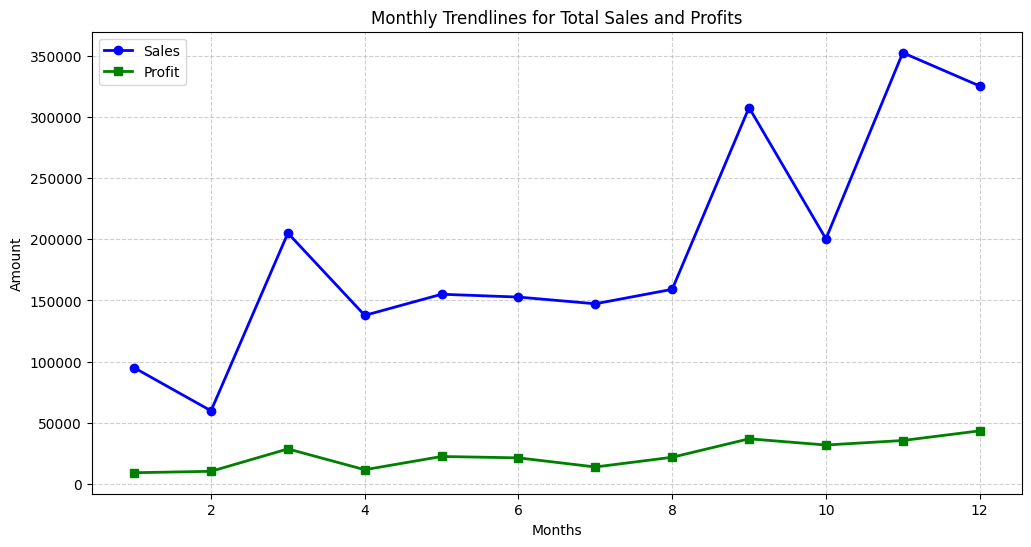

In [36]:
# Monthly Trendlines for Total Sales & Profits
plt.figure(figsize=(12, 6))
plt.plot(EDA5['Months'], EDA5['Sales'], marker='o', label='Sales', color='blue', linewidth=2)
plt.plot(EDA5['Months'], EDA5['Profit'], marker='s', label='Profit', color='green', linewidth=2)

plt.title('Monthly Trendlines for Total Sales and Profits')
plt.xlabel('Months')
plt.ylabel('Amount')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

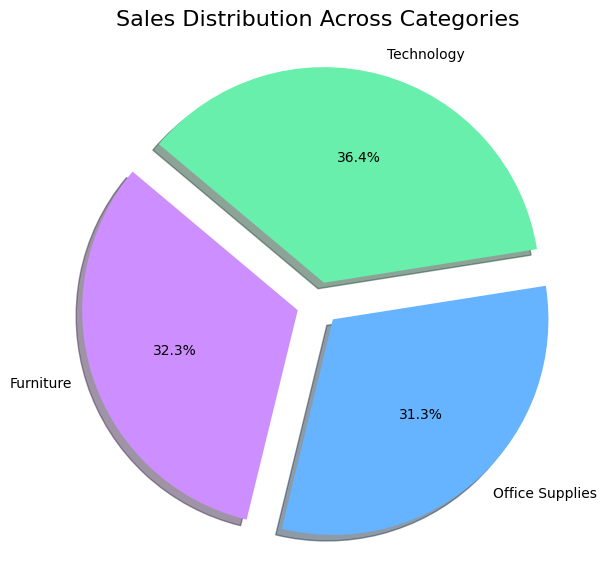

In [37]:
# Sales Distribution Across Categories
plt.figure(figsize=(10,7))

plt.pie(
    EDA6['Sales'], 
    labels=EDA6['Category'], 
    autopct='%1.1f%%',
    explode = (0.1, 0.1, 0.1),
    shadow=True,
    startangle=140,
    colors=["#cd8fff",'#66b3ff',"#67efab"]
)

plt.title('Sales Distribution Across Categories', fontsize=16)
plt.show()

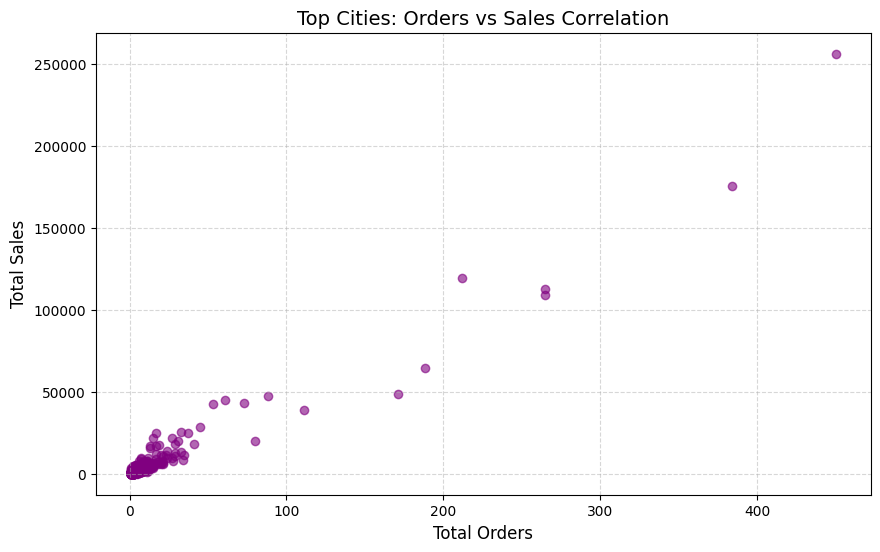

In [38]:
# Top Cities: Orders vs Sales Correlation
plt.figure(figsize=(10, 6))

plt.scatter(EDA7['Total Orders'], EDA7['Total Sales'], color='purple', alpha=0.6)

plt.title('Top Cities: Orders vs Sales Correlation', fontsize=14)
plt.xlabel('Total Orders', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

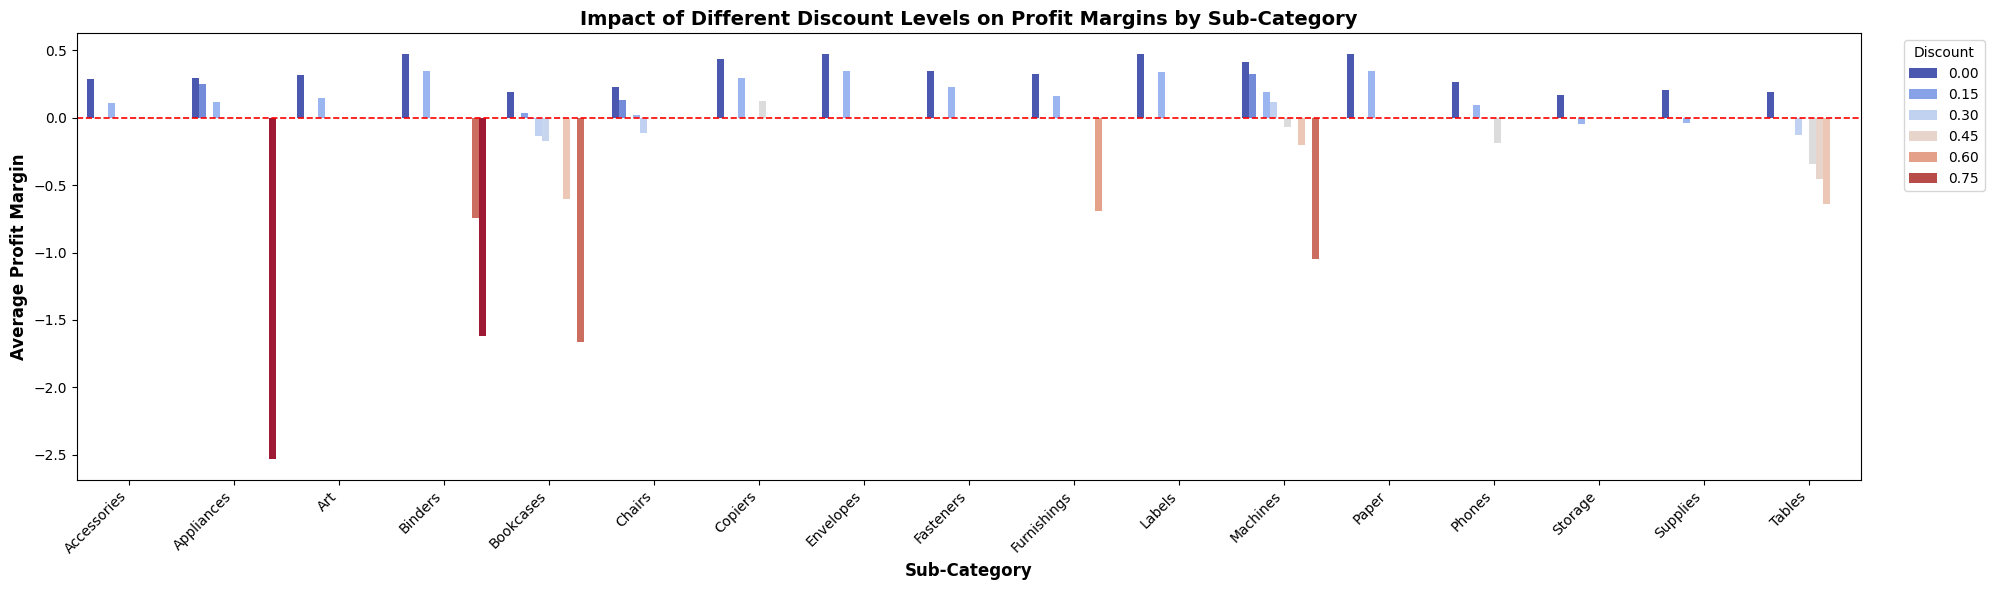

In [39]:
# Impact of Different Discount Levels on Profit Margins by Sub-Category
plt.figure(figsize=(20, 6))

sns.barplot(data=EDA8, x='Sub-Category', y='Profit Margin', hue='Discount', palette='coolwarm')

plt.title('Impact of Different Discount Levels on Profit Margins by Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Sub-Category', fontweight='bold', fontsize=12)
plt.ylabel('Average Profit Margin', fontweight='bold', fontsize=12)

plt.axhline(0, color='red', linestyle='--', linewidth=1.2)

plt.xticks(rotation=45, ha='right')
plt.legend(title='Discount', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

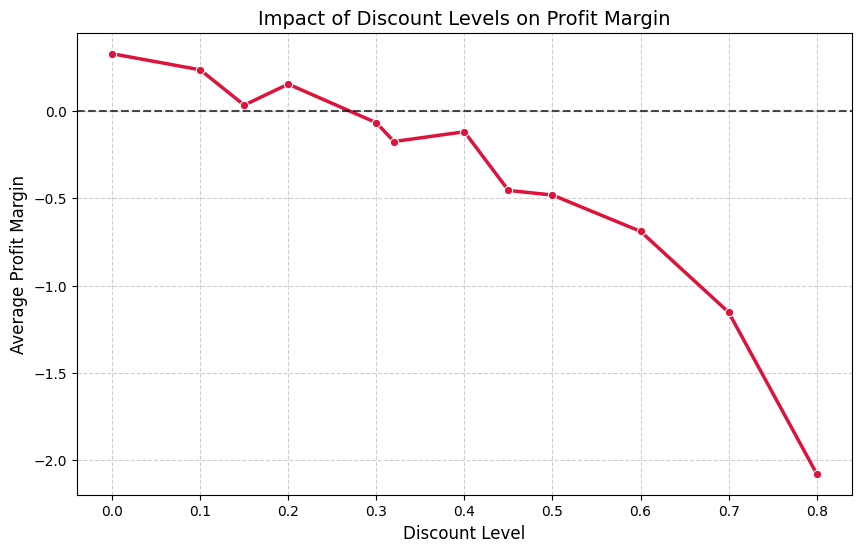

In [40]:
# Impact of Discount Levels on Profit Margin
plt.figure(figsize=(10, 6))


sns.lineplot(
    data=EDA8, 
    x='Discount', 
    y='Profit Margin', 
    marker='o', 
    color='crimson', 
    linewidth=2.5,
    errorbar=None 
)

plt.title('Impact of Discount Levels on Profit Margin', fontsize=14)
plt.xlabel('Discount Level', fontsize=12)
plt.ylabel('Average Profit Margin', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.7) # line before start losing
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

<a id='conclusions'></a>
## **6. Conclusions**

### Summary of Findings
Based on the graphs and data analysis of the SuperStore dataset, we found the following:
* **Customer Segments:** The Consumer segment contributes the highest total revenue and order volume, while segment profitability varies significantly based on discount applications.

* **Geographic Profitability:** Negative profits and losses are heavily concentrated in specific states, driven largely by aggressive discount strategies rather than low sales volume.

* **Discount Impact:** High discount levels directly erode profit margins, pushing transactions and specific sub-categories past the break-even point into net losses.

* **Sales & Orders Distribution:** Sales and order volumes are heavily skewed toward top-tier metropolitan cities (such as New York City and Los Angeles), demonstrating a strong concentration of high-value business activity.

* **Temporal Trends:** Sales and profits exhibit notable seasonal fluctuations throughout the year, with major spikes during peak months (such as late Q3 and Q4).

### Limitations
Keep in mind a few limitations of this analysis:
* **Correlation, Not Causation:** The findings show patterns and trends regarding discounts, segments, and profits, but they do not definitively prove that one single factor directly causes net losses without controlling for other variables.

* **Missing Factors:** The dataset does not include external economic indicators, local market competition, or marketing campaign costs, which could also influence customer purchasing behavior and regional profitability.

<a id='recommendations'></a>
## **7. Recommendations**

Based on the exploratory data analysis and the patterns observed in the SuperStore dataset, here are actionable recommendations to help business stakeholders improve profitability, optimize sales strategies, and mitigate losses:

* **Revise Discount Strategies on Vulnerable Sub-Categories:** Since data shows that high discount levels directly erode profit margins and push transactions into net losses, management should set strict threshold caps on discounts, particularly for sub-categories prone to negative returns.

* **Target High-Loss States:** Given that negative profits are heavily concentrated in specific states, the company should conduct regional pricing and shipping audits, or reallocate marketing and promotional budgets toward higher-margin geographic areas.

* **Focus on High-Value Customer Retention:** Capitalize on top-tier customers and high-volume segments (such as Consumer) by introducing loyalty incentives, personalized marketing campaigns, and streamlined purchasing workflows to maximize customer lifetime value.

* **Optimize Shipping and Regional Logistics:** Investigate shipping durations across high-volume cities and states to ensure that fulfillment efficiency aligns with sales volume, preventing operational bottlenecks in top-performing markets like New York City and Los Angeles.

* **Further Investigation:** Because this analysis is observational, management should consider gathering additional data (such as marketing acquisition costs, localized economic conditions, and competitor pricing) to run predictive machine learning models and uncover deeper root causes for product unprofitability.